In [ ]:
# Number of posts
num_posts = len(df)

# Text length statistics
df['title_length'] = df['title'].apply(len)
df['text_length'] = df['text'].fillna('').apply(len)

avg_title_length = df['title_length'].mean()
avg_text_length = df['text_length'].mean()

# Storage size
file_size_mb = round(df.memory_usage(deep=True).sum() / (1024 * 1024), 2)
print(num_posts)
print(avg_title_length)
print(avg_text_length)
print(file_size_mb)

In [21]:
import pandas as pd
import chardet

try:
    # Detect encoding
    with open("full data.csv", "rb") as f:
        raw_data = f.read()
    result = chardet.detect(raw_data)
    encoding = result['encoding']
    print(f"Detected encoding: {encoding}")

    # Load the file with the detected encoding
    df = pd.read_csv("full data.csv", encoding=encoding, on_bad_lines='skip')

except UnicodeDecodeError:
    print("Failed to decode with detected encoding. Trying fallback encodings...")
    # Try common fallback encodings
    for encoding in ['latin1', 'ISO-8859-1', 'Windows-1252']:
        try:
            df = pd.read_csv("full data.csv", encoding=encoding, on_bad_lines='skip')
            print(f"Successfully loaded file with encoding: {encoding}")
            break
        except UnicodeDecodeError:
            continue

# Validate the loaded data
print(df.shape)
print(df.head())
print(df.isnull().sum())

Detected encoding: UTF-8-SIG
Failed to decode with detected encoding. Trying fallback encodings...
Successfully loaded file with encoding: latin1
(144271, 11)
     ï»¿id                                              title  \
0  1j2uo4z  Can someone explain to me Why Chatgpt Can't ge...   
1  1j2ji1u  Built a system that is many percent better tha...   
2  1j2hv9i                 What is a term for opposite of AI?   
3  1j24mkx  OpenAI Expands Sora Globally Plans ChatGPT Int...   
4  1j1n5hf  As of today, is AI making you more creative an...   

                                                text score num_comments  \
0  This baffles me, It's insane to me how I can a...     8           66   
1  The system IÃ¢â¬Ú©ve built scores higher than...     0           50   
2  I imagine myself doing a pitch soon so what do...     0           37   
3                                                NaN     1            1   
4  I'm seeing a trend where people who use ChatGP...     1           20   


<ipython-input-21-7bda1650430a>:20: DtypeWarning: Columns (3,4,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("full data.csv", encoding=encoding, on_bad_lines='skip')


In [22]:
import pandas as pd

# Load dataset (assuming it's already cleaned and encoded properly)
df = pd.read_csv("full data.csv", encoding='ISO-8859-1', on_bad_lines='skip')

# Function to count words in a string
def word_count(text):
    if isinstance(text, str):  # Ensure the value is a string
        return len(text.split())  # Split by whitespace and count words
    return 0  # Return 0 for missing or non-string values

# Apply word count to title and text columns
df['title_word_count'] = df['title'].apply(word_count)
df['text_word_count'] = df['text'].fillna('').apply(word_count)  # Fill NaN with empty string

# Calculate average word counts
avg_title_word_count = df['title_word_count'].mean()
avg_text_word_count = df['text_word_count'].mean()

# Print results
print(f"Average Title Word Count: {avg_title_word_count:.2f}")
print(f"Average Text Word Count: {avg_text_word_count:.2f}")

<ipython-input-22-934c3d6e77b0>:4: DtypeWarning: Columns (3,4,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("full data.csv", encoding='ISO-8859-1', on_bad_lines='skip')


Average Title Word Count: 11.29
Average Text Word Count: 162.62


<ipython-input-23-2cc6dcacc6f3>:5: DtypeWarning: Columns (3,4,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("full data.csv", encoding='ISO-8859-1', on_bad_lines='skip')


     year  post_count
0  2022.0        1148
1  2023.0       25046
2  2024.0       16502
3  2025.0        9854


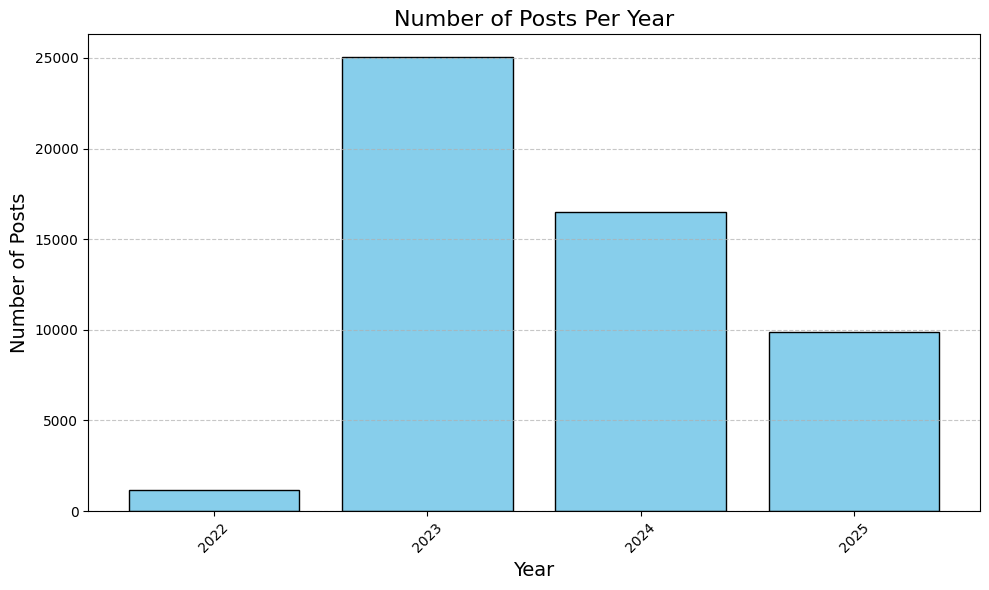

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (assuming it's already cleaned and encoded properly)
df = pd.read_csv("full data.csv", encoding='ISO-8859-1', on_bad_lines='skip')

# Parse timestamp (assuming format is '3/1/2025 21:01 PM')
df['created_utc'] = pd.to_datetime(df['created_utc'], format="%m/%d/%Y %H:%M", errors='coerce')

# Normalize to just the date
df['created_date'] = df['created_utc'].dt.normalize()

# Extract year
df['year'] = df['created_date'].dt.year

# Drop rows with missing or invalid dates
df = df.dropna(subset=['year'])

# Count posts per year
year_counts = df.groupby('year').size()

# Convert to DataFrame for better readability
year_counts_df = year_counts.reset_index(name='post_count')

# Sort by year
year_counts_df = year_counts_df.sort_values(by='year')

# Print results
print(year_counts_df)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.bar(year_counts_df['year'], year_counts_df['post_count'], color='skyblue', edgecolor='black')
plt.title("Number of Posts Per Year", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Posts", fontsize=14)
plt.xticks(year_counts_df['year'], rotation=45)  # Ensure x-axis shows all years
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()